                             EUA              ESG           Supply           Demand             Risk
           Mean          0.0012          0.0004         -0.0001          0.0000          0.0005
         Median          0.0008          0.0008         -0.0030          0.0711          0.0063
      Std. Dev.          0.0275          0.0094          0.0240          0.8098          0.1230
            Min         -0.1887         -0.0971         -0.1009         -6.7590         -2.4811
            Max          0.1657          0.0771          0.2418          9.4729          1.7214
       Skewness         -0.4226         -0.9563          1.6814         -0.4722         -2.8297
      Ex. Kurt.          4.8403         15.5121          9.7225         14.3770         95.1697
--------------------------------------------------------------------------------------------------------------
    Jarque-Bera       2279.3***      23078.4***      10000.0***      19610.4***     858907.0***
            ADF     

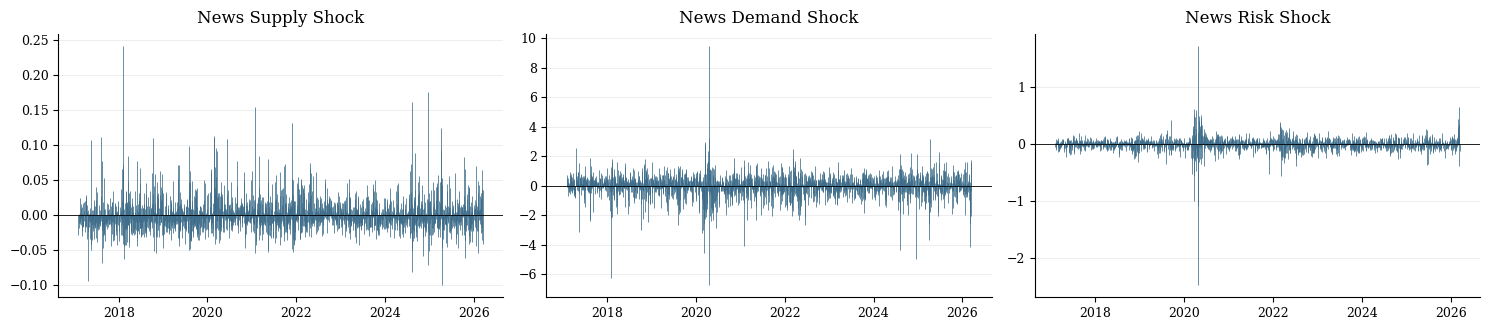

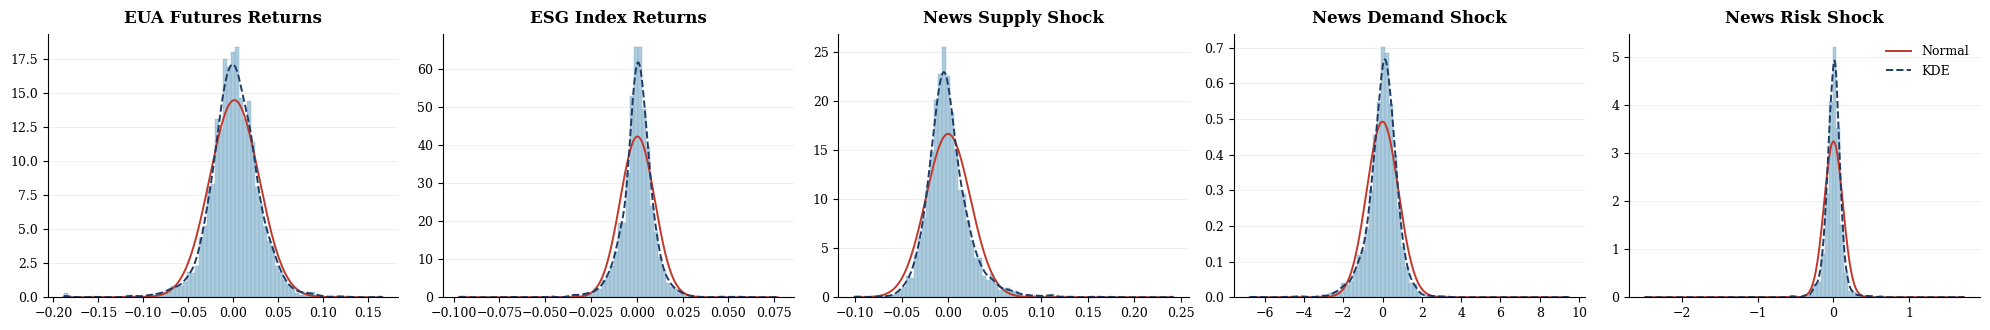

In [1]:
# =========================================================================
# PURPOSE
#   Produce the descriptive statistics needed for Table 1 of the master
#   thesis as well as the lower-triangular correlation matrix and p-values 
#   that accompany it. Besides of that, News shocks time series and 
#   unconditional distributions of the five series are created. 
#   The script reports, for each of the five series {EUA, ESG, Supply, Demand, Risk}: 
#   mean, median, standard deviation,   minimum, maximum, skewness 
#   and excess kurtosis, together with battery of standard time-series 
#   tests:
#
#     - Jarque-Bera   (H0: normality of the unconditional distribution),
#     - Augmented Dickey-Fuller (H0: a unit root is present),
#     - Ljung-Box  Q(10)        (H0: no autocorrelation up to lag 10),
#     - Engle's ARCH(5) LM test (H0: no ARCH effects up to lag 5).
#
#   Significance levels are flagged with the usual asterisk convention
#   (*** p<0.01, ** p<0.05, * p<0.10) via the small `stars` helper.
#
#   Dataset:    Data.xlsx
#   Sample:     2017-02-03 to 2026-03-16  (2,278 daily observations)
# =========================================================================

import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import pearsonr, gaussian_kde, norm
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from Functions import stars, calculate_pvalues

# -------------------------------------------------------------------------
# Load data and assign short, table-friendly column labels
# -------------------------------------------------------------------------
df = pd.read_excel(
    '/Users/johannesfelchner/Desktop/Code/Section 4/Section 4.2/Data.xlsx'
)
df.set_index("Date", inplace=True)
df.columns = ["EUA", "ESG", "Supply", "Demand", "Risk"]

# -------------------------------------------------------------------------
# Compute moments and diagnostic tests column by column
# -------------------------------------------------------------------------
# The dictionary `results` is keyed by the series name and contains every
# value that will later be printed in Table 1, including each test's
# significance flag.
results = {}
for c in df.columns:
    s = df[c].dropna()

    # Sample moments.
    mean   = s.mean()
    median = s.median()
    std    = s.std()
    mn     = s.min()
    mx     = s.max()
    skw    = s.skew()
    kurt   = s.kurtosis()       # pandas returns *excess* kurtosis

    # Jarque-Bera test (H0: normality).
    jb_stat, jb_p = stats.jarque_bera(s)

    # 3c. Augmented Dickey-Fuller test (H0: presence of a unit root).
    #     `autolag='AIC'` lets statsmodels pick the lag length that
    #     minimises AIC inside the ADF regression.
    adf_res  = adfuller(s, autolag='AIC')
    adf_stat = adf_res[0]
    adf_p    = adf_res[1]

    # 3d. Ljung-Box Q(10) test (H0: no autocorrelation in the first 10 lags).
    lb       = acorr_ljungbox(s, lags=[10], return_df=True)
    lb_stat  = lb['lb_stat'].values[0]
    lb_p     = lb['lb_pvalue'].values[0]

    # 3e. Engle's ARCH(5) LM test (H0: no ARCH effects up to lag 5).
    lm_stat, lm_p, _, _ = het_arch(s, nlags=5)

    results[c] = {
        'Mean':        mean,
        'Median':      median,
        'Std. Dev.':   std,
        'Min':         mn,
        'Max':         mx,
        'Skewness':    skw,
        'Ex. Kurt.':   kurt,
        'JB':          jb_stat,
        'JB_p':        jb_p,
        'JB_stars':    stars(jb_p),
        'ADF':         adf_stat,
        'ADF_p':       adf_p,
        'ADF_stars':   stars(adf_p),
        'Q10':         lb_stat,
        'Q10_p':       lb_p,
        'Q10_stars':   stars(lb_p),
        'ARCH5':       lm_stat,
        'ARCH5_p':     lm_p,
        'ARCH5_stars': stars(lm_p),
    }

# -------------------------------------------------------------------------
# Render Table 1 with fixed-width formatting
# -------------------------------------------------------------------------
print("=" * 110)
print(f"{'':>15s} {'EUA':>16s} {'ESG':>16s} {'Supply':>16s} {'Demand':>16s} {'Risk':>16s}")
print("=" * 110)

# 4a. Block of moments (no significance stars).
rows = [
    ('Mean',      'Mean',      '{:.4f}'),
    ('Median',    'Median',    '{:.4f}'),
    ('Std. Dev.', 'Std. Dev.', '{:.4f}'),
    ('Min',       'Min',       '{:.4f}'),
    ('Max',       'Max',       '{:.4f}'),
    ('Skewness',  'Skewness',  '{:.4f}'),
    ('Ex. Kurt.', 'Ex. Kurt.', '{:.4f}'),
]
for label, key, fmt in rows:
    vals = [fmt.format(results[c][key]) for c in df.columns]
    print(f"{label:>15s}" + "".join(f"{v:>16s}" for v in vals))

print("-" * 110)

# Block of test statistics with significance stars appended.
test_rows = [
    ('Jarque-Bera', 'JB',    'JB_stars',    '{:.1f}'),
    ('ADF',         'ADF',   'ADF_stars',   '{:.4f}'),
    ('Q(10)',       'Q10',   'Q10_stars',   '{:.3f}'),
    ('ARCH(5)',     'ARCH5', 'ARCH5_stars', '{:.3f}'),
]
for label, key, star_key, fmt in test_rows:
    vals = [fmt.format(results[c][key]) + results[c][star_key] for c in df.columns]
    print(f"{label:>15s}" + "".join(f"{v:>16s}" for v in vals))

print("=" * 110)
print(f"{'Observations':>15s}" + "".join(f"{'2,278':>16s}" for _ in df.columns))

# -------------------------------------------------------------------------
# Correlation matrix and p-values
# -------------------------------------------------------------------------

df_numeric = df.select_dtypes(include=[np.number]).dropna()

r_values, p_values = calculate_pvalues(df_numeric)

print("\n\n" + "=" * 80)
print("Correlation Matrix")
print("=" * 80)

# Print lower-triangular r_matrix
for i, row_name in enumerate(df_numeric.columns):
    vals = []
    for j, col_name in enumerate(df_numeric.columns):
        if j <= i:
            vals.append(f"{r_values.iloc[i, j]:.4f}")
        else:
            vals.append("")
    print(f"{row_name:>10s}" + "".join(f"{v:>12s}" for v in vals))

print("\n\n" + "=" * 80)
print("Significance Levels")
print("=" * 80)

# Print lower-triangular p_matrix 
for i, row_name in enumerate(df_numeric.columns):
    vals = []
    for j, col_name in enumerate(df_numeric.columns):
        if j < i:
            vals.append(f"{p_values.iloc[i, j]:.4f}")
        elif j == i:
            vals.append("-") 
        else:
            vals.append("")
    print(f"{row_name:>10s}" + "".join(f"{v:>12s}" for v in vals))

# -------------------------------------------------------------------------
# Sample-period footer
# -------------------------------------------------------------------------
print("\n\nSample period: 2017-02-03 to 2026-03-16")
print(f"Observations:  {len(df)}")

# =========================================================================
# FIGURE 1: News shocks time series
# -------------------------------------------------------------------------
# Three side-by-side panels showing the daily Supply, Demand and Risk
# news shocks as vertical bars. 
# =========================================================================

# Global style: serif font, light gridlines, no top/right spines.
plt.rcParams.update({
    'font.family':    'serif',
    'font.serif':     ['DejaVu Serif'],
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '-',
    'grid.linewidth':    0.5,
})

shock_cols   = ['Supply', 'Demand', 'Risk']
shock_titles = ['News Supply Shock', 'News Demand Shock', 'News Risk Shock']
bar_color    = '#3d6c8a'   # muted steel-blue, like in the reference figure

fig, axes = plt.subplots(1, 3, figsize=(15, 3.4))

for ax, col, title in zip(axes, shock_cols, shock_titles):
    series = df[col].dropna()
    # Vertical lines from zero up to the value of each observation -- this
    # reproduces the "stick" look of the reference plot more faithfully
    # than a continuous line plot would.
    ax.vlines(series.index, ymin=0, ymax=series.values,
              color=bar_color, linewidth=0.6, alpha=0.9)
    ax.axhline(0, color='black', linewidth=0.6)

    ax.set_title(title, fontsize=12, pad=8)

    # X-axis: yearly ticks, rotated horizontally.
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='both', labelsize=9)

    # Hide vertical gridlines, keep horizontal ones (matches the reference).
    ax.xaxis.grid(False)
    ax.yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_news_shocks_timeseries.pdf', bbox_inches='tight')
plt.show()

# =========================================================================
# FIGURE 2: Unconditional distributions of the five series
# -------------------------------------------------------------------------
# For each series we overlay:
#   * a density-normalised histogram (light blue),
#   * the fitted Normal pdf with mean = sample mean and sd = sample std
#     (red, solid), and
#   * a Gaussian kernel-density estimate (dark blue, dashed).
# =========================================================================

dist_cols = ['EUA', 'ESG', 'Supply', 'Demand', 'Risk']
dist_titles = ['EUA Futures Returns', 'ESG Index Returns',
               'News Supply Shock', 'News Demand Shock', 'News Risk Shock']

fig, axes = plt.subplots(1, 5, figsize=(20, 3.4))

for ax, col, title in zip(axes, dist_cols, dist_titles):
    s = df[col].dropna().values
    mu, sigma = s.mean(), s.std()

    # Histogram (density-normalised so that all three curves share a
    # common y-axis interpretation).
    ax.hist(s, bins=80, density=True,
            color='#9ec3d8', edgecolor='#7aa6c2', linewidth=0.3, alpha=0.85)

    # Fitted Normal density on a fine grid.
    x_grid = np.linspace(s.min(), s.max(), 500)
    ax.plot(x_grid, norm.pdf(x_grid, mu, sigma),
            color='#c0392b', linewidth=1.4, label='Normal')

    # Gaussian kernel-density estimate.
    kde = gaussian_kde(s)
    ax.plot(x_grid, kde(x_grid),
            color='#1f3b66', linewidth=1.4, linestyle='--', label='KDE')

    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    ax.tick_params(axis='both', labelsize=9)
    ax.xaxis.grid(False)
    ax.yaxis.grid(True, alpha=0.3)

# Legend only on the last panel (matches the reference layout).
axes[-1].legend(loc='upper right', frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig('fig_distributions.pdf', bbox_inches='tight')
plt.show()